# *Streptococcus suis* antiphage defence — figure & statistics notebook

Clean, self-contained pipeline for the Python figures and statistics in the
*S. suis* defence draft. Run top to bottom; every figure is written to `figures/`
with the exact filename used in the manuscript.

**Layout**
1. Setup (imports, paths, helpers)
2. Load & assemble data  *(the only "wrangling" — kept tight)*
3. Summary statistics (numbers quoted in Results + Table 1)
4. **Figure 2** — defence richness vs gene count by outcome → `OutcomeVsCount.pdf`
5. **Figure 3 stats** — within-bin *tmn*-α Mann–Whitney tests (feeds Fig 3 markers)
6. **Figure 3** — prevalence heatmap + genome-size histogram → `HeatmapAndHistogram_noUbiq.pdf`
7. **Figure 4** — PCA of defence profiles → `PCA_Draft3.png`
8. **Figure 5** — co-occurrence (binomial-exact) heatmap → `defence_cooccurrence_heatmap.png`

**Not in this notebook** (see `README.md`): Figure 1 / S2 defence network → R scripts in
`figure1_network_R/`; Figure 6 phylogenetic tree → iToL (annotation files in
`supporting_scripts/itol/`); Figure 7 reconciliation → GeneRax/ThirdKind/AlphaFold.

Input data live in `data/`. Nothing outside this folder is read.

## 1. Setup

In [1]:

import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from scipy import stats
from scipy.stats import binom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests

# Plotting defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Directories (relative to this notebook)
DATA_DIR = Path('data')
FIG_DIR  = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR  = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# Input files
DEFENCE_FILE   = DATA_DIR / 'ssuis_defence_CLEANED.csv'
BVBRC_FILE     = DATA_DIR / 'Ssuis_BVBRC_29Nov23.csv'
SEROTYPE_FILE  = DATA_DIR / 'ConsensusSerotypes_23Jul24.csv'
COLOURS_FILE   = DATA_DIR / 'serotype_colours.csv'
TMN_BETA_FILE  = DATA_DIR / 'SmallCluster_Tmngenes.txt'   # small CLANS cluster = tmn-beta


def normalise_genome_id(genome_id):
    """Genome IDs to a consistent string (strip trailing .gff / whitespace)."""
    s = str(genome_id)
    if s.endswith('.gff'):
        s = s[:-4]
    return s.strip()


def parse_defence_column(col):
    """Header 'TYPE#x#SUBTYPE#y#OUTCOME#z' -> dict, or None if not a defence column."""
    col = col.strip()
    parts = col.split('#')
    if not col.startswith('TYPE#') or len(parts) != 6:
        return None
    return {'type': parts[1].strip(), 'subtype': parts[3].strip(),
            'outcome': parts[5].strip(), 'column': col}


def categorise_outcome(outcome):
    """Map raw outcome string to a category."""
    o = outcome.lower().strip()
    if o == 'abi':                              return 'Abi'
    if o == 'non-abi':                          return 'Non-abi'
    if 'possible' in o:                         return 'Possible_abi'
    if 'unresolved' in o or 'unmapped' in o:    return 'Unresolved'
    return 'Unknown'

print('Setup complete.')

Setup complete.


## 2. Load & assemble data

Three reads (defence matrix, BV-BRC metadata, serotypes) plus the *tmn*-β genome list.
We build:

- `defence_df` — raw per-genome gene **counts** (original single *tmn* column)
- `defence_df_tmn_split` — same matrix with *tmn* split into **`tmn-alpha`** / **`tmn-beta`** presence flags (the matrix used for Figs 3–5 and the stats)
- `defence_metadata` — type / subtype / outcome for every column of the split matrix
- `merged_df` — split matrix + serotype + genome size/CDS
- `prevalence_df` — per-subtype prevalence table

In [2]:

# --- 2a. Defence matrix + column metadata -------------------------------------
defence_raw = pd.read_csv(DEFENCE_FILE, dtype={'genome_id': str})
defence_raw['genome_id'] = defence_raw['genome_id'].apply(normalise_genome_id)

defence_metadata = {}
for col in defence_raw.columns:
    info = parse_defence_column(col)
    if info:
        info['outcome_category'] = categorise_outcome(info['outcome'])
        defence_metadata[col] = info

defence_df = defence_raw.set_index('genome_id')
defence_df = defence_df[[c for c in defence_df.columns if c in defence_metadata]]

# Merge the two duplicate Gao_Mza / Gao_mza columns into one
gao_cols = [c for c in defence_df.columns if 'gao_mza' in c.lower()]
if len(gao_cols) > 1:
    canonical = 'TYPE#Gao_Mza#SUBTYPE#Gao_Mza#OUTCOME#Unknown'
    merged_vals = defence_df[gao_cols].sum(axis=1)
    defence_df = defence_df.drop(columns=gao_cols)
    defence_df[canonical] = merged_vals
    for c in gao_cols:
        defence_metadata.pop(c, None)
    defence_metadata[canonical] = {'type': 'Gao_Mza', 'subtype': 'Gao_Mza',
                                   'outcome': 'Unknown', 'column': canonical,
                                   'outcome_category': 'Unknown'}

print(f"Loaded {defence_df.shape[0]} genomes x {defence_df.shape[1]} defence columns")

Loaded 2119 genomes x 148 defence columns


In [3]:

# --- 2b. Split tmn into tmn-alpha / tmn-beta ----------------------------------
# tmn-beta = genomes in the small CLANS cluster; tmn-alpha = the rest with tmn.
# 1307.448 and 1307.958 genuinely carry BOTH variants.
defence_df_tmn_split = defence_df.copy()
tmn_cols = [c for c in defence_df_tmn_split.columns if 'tmn' in c.lower()]
assert len(tmn_cols) == 1, f"Expected exactly one tmn column, found {tmn_cols}"
tmn_col = tmn_cols[0]

both_versions = {'1307.448', '1307.958'}
# cap raw counts to presence (1), then restore the two genuine both-variant genomes
defence_df_tmn_split[tmn_col] = defence_df_tmn_split[tmn_col].clip(upper=1)
for g in both_versions:
    if g in defence_df_tmn_split.index:
        defence_df_tmn_split.loc[g, tmn_col] = 2

tmn_beta_genomes = set()
with open(TMN_BETA_FILE) as fh:
    for line in fh:
        line = line.strip()
        if line:
            tmn_beta_genomes.add(str(line.split('@')[0]))

alpha_col = 'TYPE#tmn#SUBTYPE#tmn-alpha#OUTCOME#Unknown'
beta_col  = 'TYPE#tmn#SUBTYPE#tmn-beta#OUTCOME#Unknown'

genomes_with_tmn = set(defence_df_tmn_split[defence_df_tmn_split[tmn_col] >= 1].index.astype(str))
beta_genomes  = (genomes_with_tmn & tmn_beta_genomes) | both_versions
alpha_genomes = (genomes_with_tmn - tmn_beta_genomes) | both_versions

defence_df_tmn_split[alpha_col] = defence_df_tmn_split.index.astype(str).isin(alpha_genomes).astype(int)
defence_df_tmn_split[beta_col]  = defence_df_tmn_split.index.astype(str).isin(beta_genomes).astype(int)
defence_df_tmn_split = defence_df_tmn_split.drop(columns=[tmn_col])

# Keep metadata aligned to the split matrix (drop tmn, add alpha/beta)
defence_metadata.pop(tmn_col, None)
defence_metadata[alpha_col] = {'type': 'tmn', 'subtype': 'tmn-alpha', 'outcome': 'Unknown',
                               'column': alpha_col, 'outcome_category': 'Unknown'}
defence_metadata[beta_col]  = {'type': 'tmn', 'subtype': 'tmn-beta', 'outcome': 'Unknown',
                               'column': beta_col, 'outcome_category': 'Unknown'}

n_alpha = int(defence_df_tmn_split[alpha_col].sum())
n_beta  = int(defence_df_tmn_split[beta_col].sum())
n_both  = int(((defence_df_tmn_split[alpha_col] == 1) & (defence_df_tmn_split[beta_col] == 1)).sum())
print(f"tmn-alpha: {n_alpha} genomes | tmn-beta: {n_beta} genomes | both: {n_both} "
      f"| unique tmn genomes: {n_alpha + n_beta - n_both}")

tmn-alpha: 897 genomes | tmn-beta: 66 genomes | both: 2 | unique tmn genomes: 961


In [4]:

# --- 2c. Metadata files + merged frame ----------------------------------------
bvbrc_df = pd.read_csv(BVBRC_FILE, dtype={'Genome ID': str})
bvbrc_df.columns = bvbrc_df.columns.str.strip()
bvbrc_df['genome_id'] = bvbrc_df['Genome ID'].apply(normalise_genome_id)
bvbrc_df = bvbrc_df.set_index('genome_id')

serotype_df = pd.read_csv(SEROTYPE_FILE, dtype=str)
serotype_df['genome_id'] = serotype_df['Strain'].apply(normalise_genome_id)
serotype_df = serotype_df.set_index('genome_id')

# merged_df = split matrix + serotype + selected BV-BRC columns
merged_df = defence_df_tmn_split.copy()
merged_df = merged_df.join(serotype_df[['Serotype_Consensus']], how='left')
for col in ['Size', 'CDS', 'GC Content', 'Genome Name', 'MLST', 'Genome Status', 'Isolation Country']:
    if col in bvbrc_df.columns:
        merged_df = merged_df.join(bvbrc_df[[col]], how='left')

# Prevalence table (per subtype) from the split matrix
presence = (defence_df_tmn_split > 0).astype(int)
prevalence_df = (pd.DataFrame([
        {'column': c, 'type': i['type'], 'subtype': i['subtype'],
         'outcome': i['outcome'], 'outcome_category': i['outcome_category'],
         'n_present': int(presence[c].sum()),
         'prevalence_pct': round(100 * presence[c].sum() / len(presence), 2)}
        for c, i in defence_metadata.items()])
      .sort_values('prevalence_pct', ascending=False)
      .reset_index(drop=True))

print(f"merged_df: {merged_df.shape[0]} genomes, "
      f"{merged_df['Size'].notna().sum()} with genome size")
print(f"prevalence_df: {len(prevalence_df)} subtypes")

merged_df: 2119 genomes, 2119 with genome size
prevalence_df: 149 subtypes


## 3. Summary statistics

Numbers quoted in the Results text and Table 1, computed straight from the data.
Also writes the per-system gene-count tables used to size the Figure 1 circles
(`tables/GeneCount_of_eachDS.csv`, `tables/TYPE_Areas.tsv`).

In [5]:

n_genomes = defence_df.shape[0]

# --- Dataset ------------------------------------------------------------------
print("=" * 60); print("DATASET"); print("=" * 60)
print(f"Genomes: {n_genomes}")
if 'Genome Status' in merged_df.columns:
    status = merged_df['Genome Status'].str.strip().str.lower().value_counts()
    for k, v in status.items():
        print(f"  {k}: {v} ({100*v/n_genomes:.1f}%)")
size_mb = merged_df['Size'].dropna() / 1e6
print(f"Genome size (Mbp): {size_mb.min():.2f}-{size_mb.max():.2f} "
      f"(mean +/- SD: {size_mb.mean():.2f} +/- {size_mb.std():.2f})")

sero = merged_df['Serotype_Consensus'].fillna('Unknown').replace({'-': 'Unknown', '': 'Unknown'})
print("Top serotypes:")
for st, c in sero.value_counts().head(5).items():
    print(f"  {st}: {c} ({100*c/n_genomes:.1f}%)")

# --- Defence repertoire (raw counts) ------------------------------------------
print("\n" + "=" * 60); print("DEFENCE REPERTOIRE"); print("=" * 60)
per_genome = defence_df.sum(axis=1)
print(f"Total annotated defence proteins: {int(defence_df.values.sum()):,}")
print(f"Per genome: mean {per_genome.mean():.1f} (SD {per_genome.std():.1f}), "
      f"range {int(per_genome.min())}-{int(per_genome.max())}")
if 'CDS' in merged_df.columns:
    pct = 100 * per_genome / merged_df['CDS'].reindex(per_genome.index)
    print(f"Defence as % of CDS: mean {pct.mean():.2f}% (SD {pct.std():.2f}%)")

# Proteins per TYPE (split matrix; tmn split does not affect RM/DMS etc.)
type_of = {c: i['type'] for c, i in defence_metadata.items()}
type_totals = (defence_df_tmn_split.sum()
               .rename(index=type_of).groupby(level=0).sum()
               .sort_values(ascending=False))
print("Top defence types by protein count:")
for t, v in type_totals.head(4).items():
    print(f"  {t}: {int(v):,}")

# --- Richness counts ----------------------------------------------------------
print("\n" + "=" * 60); print("RICHNESS"); print("=" * 60)
print(f"Unique types:    {prevalence_df['type'].nunique()}")
print(f"Unique subtypes: {prevalence_df['subtype'].nunique()}")
for cat in ['Abi', 'Non-abi', 'Possible_abi', 'Unknown', 'Unresolved']:
    n = (prevalence_df['outcome_category'] == cat).sum()
    if n:
        print(f"  {cat}: {n} subtypes")

# --- Table 1: subtypes in >99% of genomes -------------------------------------
print("\n" + "=" * 60); print("TABLE 1 — subtypes in >99% of genomes"); print("=" * 60)
core = prevalence_df[prevalence_df['prevalence_pct'] > 99]
print(core[['type', 'subtype', 'outcome', 'prevalence_pct']].to_string(index=False))

# --- Figure 1 circle-area inputs ----------------------------------------------
ds_counts = defence_df_tmn_split.sum().rename('COUNT').rename_axis('DS').reset_index()
ds_counts.to_csv(TAB_DIR / 'GeneCount_of_eachDS.csv', index=False)
ds_counts['TYPE'] = ds_counts['DS'].str.split('#').str[1]
type_areas = (ds_counts.groupby('TYPE', as_index=False)['COUNT'].sum()
              .sort_values('COUNT', ascending=False).reset_index(drop=True))
type_areas['RADIUS']   = np.sqrt(type_areas['COUNT'] / np.pi)
type_areas['DIAMETER'] = type_areas['RADIUS'] * 2
type_areas.to_csv(TAB_DIR / 'TYPE_Areas.tsv', sep='\t', index=False)
prevalence_df.to_csv(TAB_DIR / 'subtype_prevalence.csv', index=False)
print(f"\nWrote tables/ -> GeneCount_of_eachDS.csv, TYPE_Areas.tsv, subtype_prevalence.csv")

DATASET
Genomes: 2119
  wgs: 1971 (93.0%)
  complete: 148 (7.0%)
Genome size (Mbp): 1.21-2.72 (mean +/- SD: 2.15 +/- 0.13)
Top serotypes:
  2: 970 (45.8%)
  Unknown: 288 (13.6%)
  7: 115 (5.4%)
  31: 86 (4.1%)
  9: 83 (3.9%)

DEFENCE REPERTOIRE
Total annotated defence proteins: 97,099
Per genome: mean 45.8 (SD 6.8), range 11-74
Defence as % of CDS: mean 2.11% (SD 0.24%)
Top defence types by protein count:
  Other: 37,862
  RM: 27,200
  CRISPR-Cas: 4,805
  DRT: 3,768

RICHNESS
Unique types:    74
Unique subtypes: 145
  Abi: 43 subtypes
  Non-abi: 19 subtypes
  Possible_abi: 10 subtypes
  Unknown: 68 subtypes
  Unresolved: 9 subtypes

TABLE 1 — subtypes in >99% of genomes
      type       subtype outcome  prevalence_pct
     Other     DMS_other Non-abi          100.00
   Thoeris Theoris_other     Abi           99.81
    Gabija        Gabija     Abi           99.67
   PD-T4-6       PD-T4-6     Abi           99.58
     Other       PDC-S07 Unknown           99.48
CRISPR-Cas CAS_Class1-IV No

## 4. Figure 2 — defence richness vs gene count, by outcome

Per genome: number of unique subtypes (x) vs total genes (y) for each outcome
category, with a linear regression line. Saved to `figures/OutcomeVsCount.pdf`.

=== REGRESSION STATISTICS ===
Abi: slope=1.60, R2=0.726, p=0.00e+00, n=2119
Non-abi: slope=1.39, R2=0.169, p=5.23e-87, n=2119
Possible_abi: slope=1.49, R2=0.754, p=0.00e+00, n=2119
Unknown: slope=1.31, R2=0.745, p=0.00e+00, n=2119


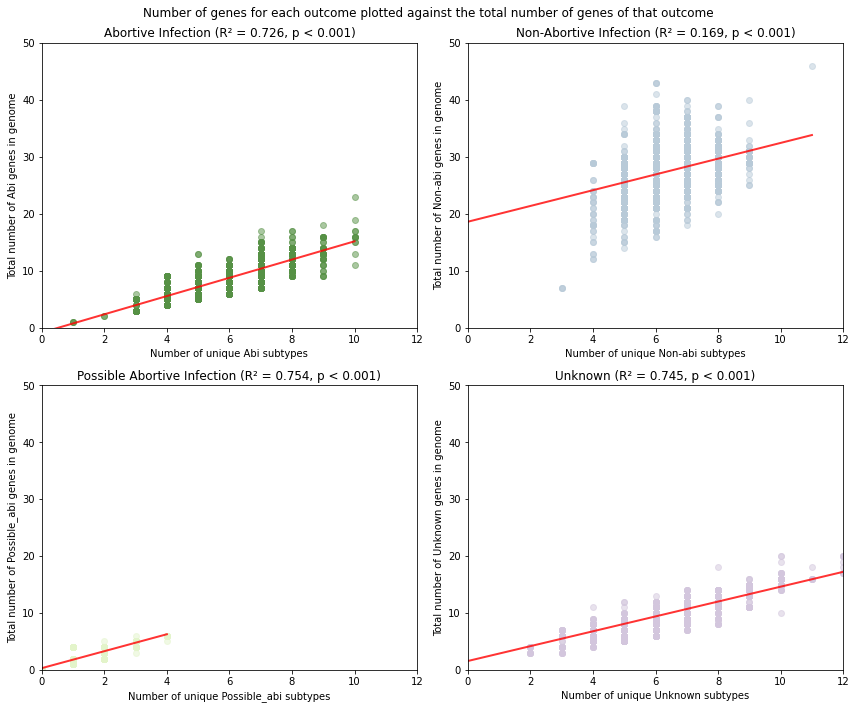

In [6]:

# Per-genome unique-subtype counts and total genes, split by outcome category.
outcomes = {
    'Abi':          ('OUTCOME#Abi',          '#569145', 'Abortive Infection'),
    'Non-abi':      ('OUTCOME#Non-abi',      '#B8CAD8', 'Non-Abortive Infection'),
    'Possible_abi': ('OUTCOME#Possible_abi', '#E3F4CA', 'Possible Abortive Infection'),
    'Unknown':      ('OUTCOME#Unknown',      '#D3C6DD', 'Unknown'),
}
cols_by_outcome = {k: [c for c in defence_df.columns if tag in c]
                   for k, (tag, _, _) in outcomes.items()}

richness = pd.DataFrame(index=defence_df.index)
for k, cols in cols_by_outcome.items():
    richness[f'{k}_systems'] = (defence_df[cols] > 0).sum(axis=1)
    richness[f'{k}_genes']   = defence_df[cols].sum(axis=1)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Number of genes for each outcome plotted against the total number "
             "of genes of that outcome")
panel = {'Abi': axs[0, 0], 'Non-abi': axs[0, 1],
         'Possible_abi': axs[1, 0], 'Unknown': axs[1, 1]}

print("=== REGRESSION STATISTICS ===")
for k, (tag, colour, title) in outcomes.items():
    ax = panel[k]
    x, y = richness[f'{k}_systems'], richness[f'{k}_genes']
    ax.scatter(x, y, alpha=0.5, color=colour)
    slope, intercept, r, p, se = stats.linregress(x, y)
    xs = np.linspace(0, x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color='red', linewidth=2, alpha=0.8)
    ax.set_title(f"{title} (R² = {r**2:.3f}, p < 0.001)")
    ax.set_xlabel(f"Number of unique {k} subtypes")
    ax.set_ylabel(f"Total number of {k} genes in genome")
    ax.set_ylim(0, 50); ax.set_xlim(0, 12)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    print(f"{k}: slope={slope:.2f}, R2={r**2:.3f}, p={p:.2e}, n={len(x)}")

plt.tight_layout()
plt.savefig(FIG_DIR / 'OutcomeVsCount.pdf', dpi=300)
plt.show()

## 5. Figure 3 statistics — within-bin *tmn*-α Mann–Whitney tests

For each 50 kb genome-size bin, compare defence gene/subtype counts in genomes
with vs without *tmn*-α (one-sided, BH-corrected). Produces `sig_bins`, which
marks the bars in Figure 3, and writes `tables/tmn_within_bin_results.csv`.

      bin  metric  n_with  n_without  mean_with  mean_without     p_adj_BH sig
1.95-2.00   Genes      52         22  35.769231     38.454545 2.667430e-02   *
1.95-2.00 Systems      52         22  13.711538     17.954545 5.075682e-10   *
2.00-2.05   Genes     308         51  40.980519     39.490196 9.653765e-01  ns
2.00-2.05 Systems     308         51  14.866883     17.901961 4.887392e-20   *
2.05-2.10   Genes     378        110  43.727513     43.109091 9.653765e-01  ns
2.05-2.10 Systems     378        110  15.576720     18.490909 1.090265e-40   *
2.10-2.15   Genes     118        249  44.296610     44.666667 9.653765e-01  ns
2.10-2.15 Systems     118        249  15.788136     18.871486 9.298341e-39   *
2.15-2.20   Genes      11        222  46.818182     46.472973 9.653765e-01  ns
2.15-2.20 Systems      11        222  17.000000     19.180180 8.112876e-04   *
2.20-2.25   Genes      14        168  44.214286     47.190476 1.059461e-01  ns
2.20-2.25 Systems      14        168  18.428571     

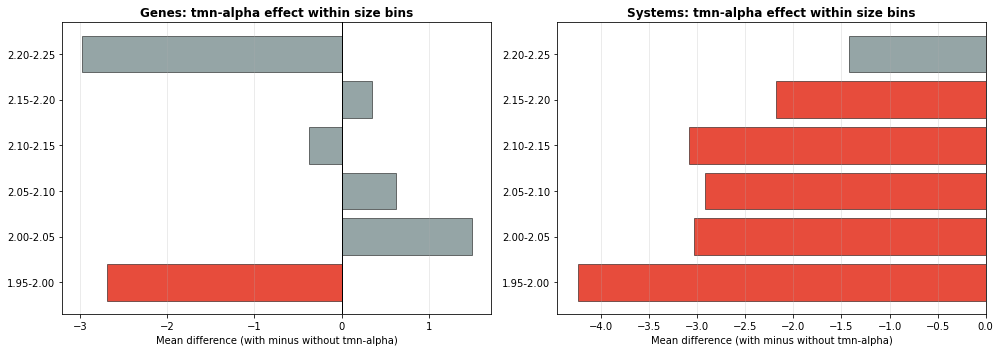

In [7]:

bin_size, min_per_group = 50000, 10
tmn_alpha = 'TYPE#tmn#SUBTYPE#tmn-alpha#OUTCOME#Unknown'
other_cols = [c for c in defence_df_tmn_split.columns if c != tmn_alpha]

analysis_df = pd.DataFrame({
    'has_tmn':      defence_df_tmn_split[tmn_alpha] >= 1,
    'gene_count':   defence_df_tmn_split[other_cols].sum(axis=1),
    'system_count': (defence_df_tmn_split[other_cols] > 0).sum(axis=1),
    'size':         merged_df.loc[defence_df_tmn_split.index, 'Size'],
})
bins = np.arange(np.floor(analysis_df['size'].min() / bin_size) * bin_size,
                 np.ceil(analysis_df['size'].max() / bin_size) * bin_size + bin_size,
                 bin_size)
analysis_df['size_bin'] = pd.cut(analysis_df['size'], bins=bins)

rows = []
for b in analysis_df['size_bin'].cat.categories:
    bdf = analysis_df[analysis_df['size_bin'] == b]
    with_t, without_t = bdf[bdf['has_tmn']], bdf[~bdf['has_tmn']]
    if len(with_t) < min_per_group or len(without_t) < min_per_group:
        continue
    label = f"{b.left/1e6:.2f}-{b.right/1e6:.2f}"
    for metric, col in [('Genes', 'gene_count'), ('Systems', 'system_count')]:
        u, p = stats.mannwhitneyu(with_t[col], without_t[col], alternative='less')
        rows.append({'bin': label, 'metric': metric,
                     'n_with': len(with_t), 'n_without': len(without_t),
                     'mean_with': with_t[col].mean(), 'mean_without': without_t[col].mean(),
                     'U': u, 'p_one_sided': p})

results_df = pd.DataFrame(rows)
for metric in ['Genes', 'Systems']:
    m = results_df['metric'] == metric
    reject, p_adj, _, _ = multipletests(results_df.loc[m, 'p_one_sided'], method='fdr_bh')
    results_df.loc[m, 'p_adj_BH'] = p_adj
    results_df.loc[m, 'sig'] = np.where(reject, '*', 'ns')

# Build sig_bins for Figure 3: '**' if genes AND systems sig, '*' if systems only
sig_bins = {}
for label in results_df['bin'].unique():
    sub = results_df[results_df['bin'] == label]
    gene_sig = (sub[sub['metric'] == 'Genes']['sig'] == '*').any()
    sys_sig  = (sub[sub['metric'] == 'Systems']['sig'] == '*').any()
    if sys_sig and gene_sig: sig_bins[label] = 'both'
    elif sys_sig:            sig_bins[label] = 'systems'

results_df.to_csv(TAB_DIR / 'tmn_within_bin_results.csv', index=False)
print(results_df[['bin', 'metric', 'n_with', 'n_without',
                  'mean_with', 'mean_without', 'p_adj_BH', 'sig']].to_string(index=False))
print(f"\nsig_bins (markers for Figure 3): {sig_bins}")

# Quick diagnostic bar plot of the within-bin effect (not a manuscript figure)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Genes', 'Systems']):
    sub = results_df[results_df['metric'] == metric].copy()
    sub['diff'] = sub['mean_with'] - sub['mean_without']
    colours = ['#e74c3c' if s == '*' else '#95a5a6' for s in sub['sig']]
    ax.barh(sub['bin'], sub['diff'], color=colours, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{metric}: tmn-alpha effect within size bins', fontweight='bold')
    ax.set_xlabel('Mean difference (with minus without tmn-alpha)')
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## 6. Figure 3 — prevalence heatmap + genome-size histogram

Top 26 subtypes (excluding >99% ubiquitous) across 50 kb genome-size bins, with
a stacked serotype histogram below. *tmn*-α significance markers come from
`sig_bins` (section 5). Saved to `figures/HeatmapAndHistogram_noUbiq.pdf`.

Plotting function defined!
Genomes with size data: 2119
Defence columns included: 144
Excluded 6 systems present in >99% of genomes: ['DMS_other', 'Theoris_other', 'Gabija', 'PD-T4-6', 'PDC-S07', 'CAS_Class1-IV']
Created heatmap: 15 bins × 26 systems
Distribution categories: ['6', '-', '2', '14', '7', '1', '16', '1_2', 'switch', '4', '3', '9', 's', '15', '10', '8', '11', 'group t', 'group s', '5', '24', '21', '28', '31', '12', '30', '25', '23', '19', '29', '18', '17', 'Chz', '27', '13']
Loaded colours for 15 serotypes
Collapsing 20 rare serotypes into 'Rarer serotypes'

Distribution columns: ['2', '14', '7', '1', '16', '1_2', '4', '3', '9', '15', '8', '5', '31', '29', 'Unknown', 'Rarer serotypes (N<20)']
Final order: ['2', '7', '31', '9', '16', '8', '3', '4', '14', '1', '1_2', '5', '29', '15', 'Rarer serotypes (N<20)', 'Unknown']
Actuall setting final order...
Duplicates in final_order: False

Bin labels: ['1.85-1.90', '1.90-1.95', '1.95-2.00', '2.00-2.05', '2.05-2.10', '2.10-2.15', '2

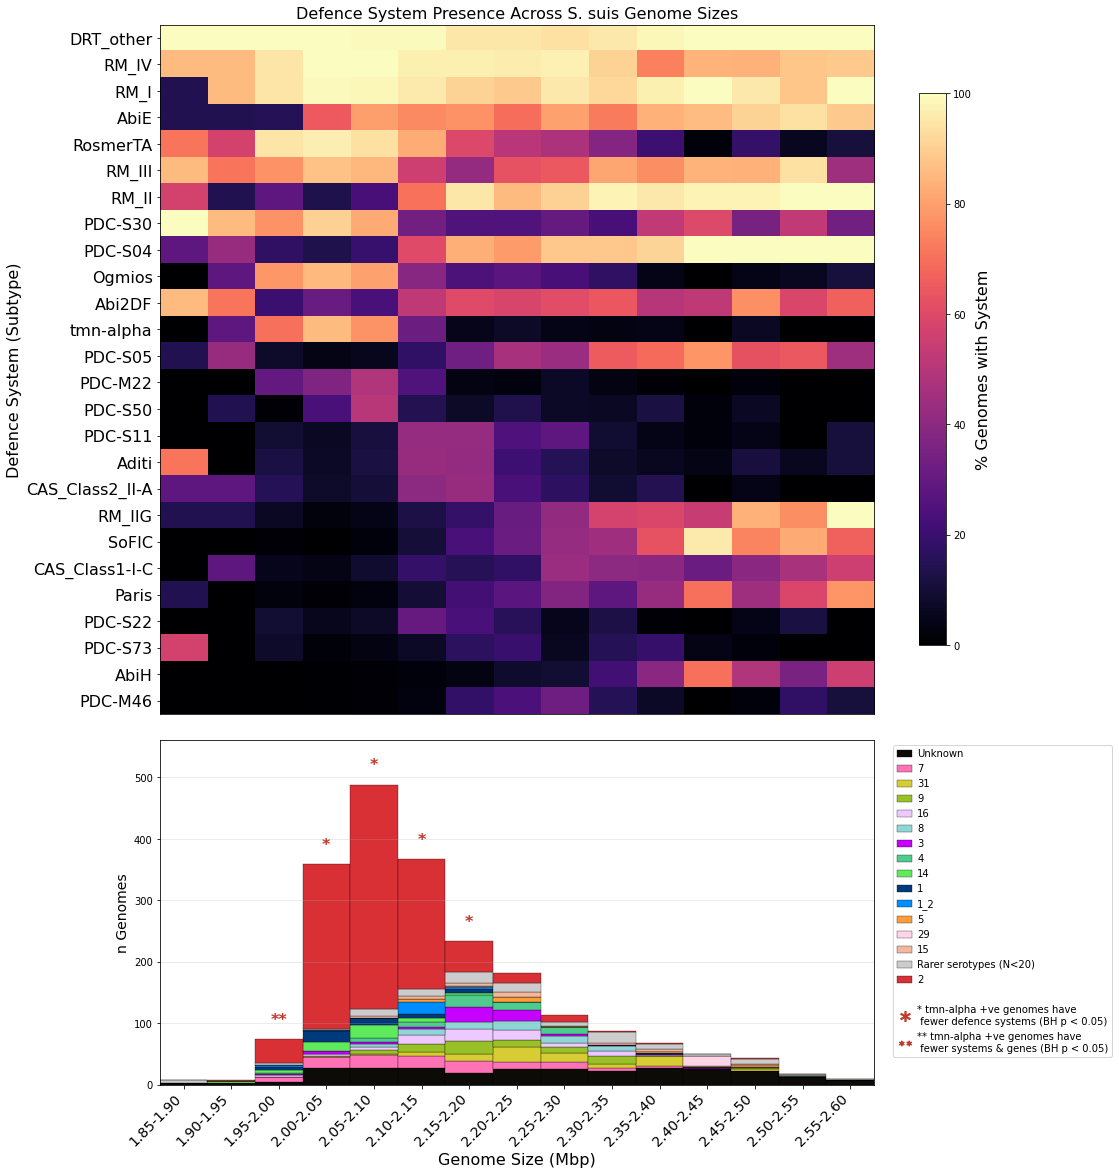


=== SUMMARY ===
Genome size range: 1.21 - 2.72 Mb
Number of size bins: 15
Systems shown: 26

Systems shown (top 26 by overall prevalence, after excluding the >99% core systems):
['DRT_other', 'RM_IV', 'RM_I', 'AbiE', 'RosmerTA', 'RM_III', 'RM_II', 'PDC-S30', 'PDC-S04', 'Ogmios', 'Abi2DF', 'tmn-alpha', 'PDC-S05', 'PDC-M22', 'PDC-S50', 'PDC-S11', 'Aditi', 'CAS_Class2_II-A', 'RM_IIG', 'SoFIC', 'CAS_Class1-I-C', 'Paris', 'PDC-S22', 'PDC-S73', 'AbiH', 'PDC-M46']


In [8]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


def plot_heatmap_with_distribution(
    heatmap_df,
    distribution_data,
    distribution_labels=None,
    colour_map=None,
    bin_labels=None,
    y_label='Defence System',
    x_label='Genome Size (Mb)',
    title='Defence System Presence Across Genome Sizes',
    cbar_label='% Genomes with System',
    output_file=None,
    sig_bins=None
):
    if bin_labels is None:
        bin_labels = heatmap_df.index.tolist()

    fig = plt.figure(figsize=(16, max(12, len(heatmap_df.columns) * 0.75)))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.05)

    # =====================================================================
    # HEATMAP (top)
    # =====================================================================
    ax_heatmap = fig.add_subplot(gs[0])
    im = ax_heatmap.imshow(
        heatmap_df.T.values,
        cmap='magma',
        aspect='auto',
        vmin=0,
        vmax=100
    )

    ax_heatmap.set_yticks(range(len(heatmap_df.columns)))
    ax_heatmap.set_yticklabels(heatmap_df.columns, fontsize=16)
    ax_heatmap.set_xticks([])
    ax_heatmap.set_ylabel(y_label, fontsize=16)
    ax_heatmap.set_title(title, fontsize=16)

    cbar = plt.colorbar(im, ax=ax_heatmap, shrink=0.8)
    cbar.set_label(cbar_label, fontsize=16)

    # =====================================================================
    # STACKED BAR CHART (bottom)
    # =====================================================================
    ax_bar = fig.add_subplot(gs[1])

    if distribution_labels is None:
        distribution_labels = distribution_data.columns.tolist()

    if colour_map is None:
        from matplotlib import cm
        n_categories = len(distribution_labels)
        colours = cm.tab20(np.linspace(0, 1, n_categories))
        colour_map = {label: colours[i] for i, label in enumerate(distribution_labels)}

    distribution_data = distribution_data[
        [col for col in distribution_labels if col in distribution_data.columns]
    ]

    x_pos = range(len(distribution_data))
    bottom = np.zeros(len(distribution_data))

    for category in distribution_data.columns:
        colour = colour_map.get(category, '#808080')
        values = distribution_data[category].values
        ax_bar.bar(
            x_pos, values, bottom=bottom,
            color=colour, edgecolor='black', linewidth=0.3, width=1.0, label=category
        )
        bottom += values

    # ---- Significance markers above bars ----
    if sig_bins:
        bar_totals = distribution_data.sum(axis=1).values
        y_offset = bar_totals.max() * 0.04

        for i, label in enumerate(bin_labels):
            match = sig_bins.get(label, None)
            if match == 'both':
                marker = '**'
            elif match == 'systems':
                marker = '*'
            else:
                continue
            bar_top = bar_totals[i]
            ax_bar.text(
                i, bar_top + y_offset, marker,
                ha='center', va='bottom',
                fontsize=16, fontweight='bold', color='#c0392b'
            )

        # Extend y-axis so asterisks stay inside axes
        ax_bar.set_ylim(0, bar_totals.max() * 1.15)

    ax_bar.set_xlabel(x_label, fontsize=16)
    ax_bar.set_ylabel('n Genomes', fontsize=14)
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=14)
    ax_bar.set_xlim(-0.5, len(distribution_data) - 0.5)
    ax_bar.grid(alpha=0.3, axis='y')

    # Legend — serotypes + significance key (compact)
    handles, labels_leg = ax_bar.get_legend_handles_labels()
    handles += [
        Line2D([0], [0], color='none', label=''),
        Line2D([0], [0], color='none', marker='$*$', markerfacecolor='#c0392b',
               markeredgecolor='#c0392b', markersize=10, linestyle='none',
               label='* tmn-alpha +ve genomes have \n fewer defence systems (BH p < 0.05)'),
        Line2D([0], [0], color='none', marker='$**$', markerfacecolor='#c0392b',
               markeredgecolor='#c0392b', markersize=12, linestyle='none',
               label='** tmn-alpha +ve genomes have \n fewer systems & genes (BH p < 0.05)'),
    ]
    ax_bar.legend(handles=handles, bbox_to_anchor=(1.02, 1),
                  loc='upper left', fontsize=10, frameon=True,
                  handlelength=1.5, handletextpad=0.5)

    pos_heatmap = ax_heatmap.get_position()
    pos_bar = ax_bar.get_position()
    ax_bar.set_position([pos_heatmap.x0, pos_bar.y0, pos_heatmap.width, pos_bar.height])

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")

    return fig, (ax_heatmap, ax_bar)

print("Plotting function defined!")


def prepare_heatmap_data_from_ssuis(
    merged_df,
    defence_metadata,
    bin_size=50000,
    min_genomes_per_bin=5,
    exclude_outcomes=None,
    exclude_subtypes=None,
    max_prevalence=None,        # NEW: exclude systems above this % (e.g. 99)
    top_n_systems=None
):
    if 'Size' not in merged_df.columns:
        print("ERROR: 'Size' column not found in merged_df")
        return None, None, None

    df = merged_df[merged_df['Size'].notna()].copy()
    print(f"Genomes with size data: {len(df)}")

    if exclude_subtypes is None:
        exclude_subtypes = ['subtype_unresolved']

    defence_cols = []
    for col, info in defence_metadata.items():
        if exclude_outcomes and info['outcome'] in exclude_outcomes:
            continue
        if info['subtype'] in exclude_subtypes:
            continue
        # Check column actually exists in the dataframe
        if col not in df.columns:
            print(f"  WARNING: skipping {info['subtype']} — column not in merged_df")
            continue
        defence_cols.append(col)

    print(f"Defence columns included: {len(defence_cols)}")

    min_size = df['Size'].min()
    max_size = df['Size'].max()
    bins = np.arange(
        np.floor(min_size / bin_size) * bin_size,
        np.ceil(max_size / bin_size) * bin_size + bin_size,
        bin_size
    )

    df['Size_bin'] = pd.cut(df['Size'], bins=bins)

    heatmap_data = []
    distribution_data = []
    bin_labels = []

    for bin_interval in df['Size_bin'].cat.categories:
        bin_genomes = df[df['Size_bin'] == bin_interval]

        if len(bin_genomes) < min_genomes_per_bin:
            continue

        heatmap_row = {}
        for col in defence_cols:
            subtype = defence_metadata[col]['subtype']
            percentage = 100 * (bin_genomes[col] > 0).sum() / len(bin_genomes)
            heatmap_row[subtype] = percentage

        heatmap_data.append(heatmap_row)

        if 'Serotype_Consensus' in bin_genomes.columns:
            serotype_counts = bin_genomes['Serotype_Consensus'].value_counts()
            distribution_data.append(serotype_counts)
        else:
            distribution_data.append(pd.Series({'All genomes': len(bin_genomes)}))

        left_mb = bin_interval.left / 1e6
        right_mb = bin_interval.right / 1e6
        bin_labels.append(f'{left_mb:.2f}-{right_mb:.2f}')

    if not heatmap_data:
        print("ERROR: No bins with sufficient genomes")
        return None, None, None

    heatmap_df = pd.DataFrame(heatmap_data, index=bin_labels)
    distribution_df = pd.DataFrame(distribution_data, index=bin_labels).fillna(0).astype(int)

    # Overall prevalence per subtype = % of ALL genomes carrying the system
    # (same definition as Table 1 and the Results text; NOT a per-bin average).
    overall_prev = pd.Series({
        defence_metadata[col]['subtype']: 100 * (df[col] > 0).sum() / len(df)
        for col in defence_cols
    })

    # Sort systems by overall prevalence (descending)
    order = overall_prev.reindex(heatmap_df.columns).sort_values(ascending=False).index
    heatmap_df = heatmap_df[order]

    # Exclude systems present in > max_prevalence % of genomes (the 'core' systems)
    if max_prevalence is not None:
        before = len(heatmap_df.columns)
        keep = [c for c in heatmap_df.columns if overall_prev[c] <= max_prevalence]
        removed = [c for c in heatmap_df.columns if c not in keep]
        heatmap_df = heatmap_df[keep]
        print(f"Excluded {before - len(keep)} systems present in >{max_prevalence}% of genomes: {removed}")

    # Keep the top N most prevalent of the remaining systems
    if top_n_systems and len(heatmap_df.columns) > top_n_systems:
        heatmap_df = heatmap_df[heatmap_df.columns[:top_n_systems]]

    print(f"Created heatmap: {len(heatmap_df)} bins × {len(heatmap_df.columns)} systems")
    print(f"Distribution categories: {list(distribution_df.columns)}")

    return heatmap_df, distribution_df, bin_labels


# ============================================================================
# USAGE
# ============================================================================

heatmap_df, distribution_df, bin_labels = prepare_heatmap_data_from_ssuis(
    merged_df=merged_df,
    defence_metadata=defence_metadata,
    bin_size=50000,
    min_genomes_per_bin=5,
    exclude_outcomes=None,
    exclude_subtypes=['subtype_unresolved'],
    max_prevalence=99,   # drop systems in >99% of genomes
    top_n_systems=26
)



# Step 2: Load serotype colours
try:
    serotype_colour_df = pd.read_csv(COLOURS_FILE, header=None)
    serotype_colour_map = {}
    serotype_order = []

    for _, row in serotype_colour_df.iterrows():
        serotype = str(row[0]).strip().strip('"').strip("'")
        colour = str(row[1]).strip().strip('"').strip("'")
        if not colour.startswith('#'):
            colour = '#' + colour
        serotype_colour_map[serotype] = colour
        serotype_order.append(serotype)

    print(f"Loaded colours for {len(serotype_colour_map)} serotypes")
except:
    print("Warning: Could not load serotype_colours.csv, will use default colours")
    serotype_colour_map = None
    serotype_order = None

# Step 3: Handle unknown and rare serotypes
distribution_df.columns = distribution_df.columns.astype(str)
unknown_variants = ['nan', 'None', '-', '', 'Unknown']

if 'Unknown' not in distribution_df.columns:
    distribution_df['Unknown'] = 0

for variant in unknown_variants:
    if variant in distribution_df.columns and variant != 'Unknown':
        distribution_df['Unknown'] = distribution_df['Unknown'] + distribution_df[variant]
        distribution_df = distribution_df.drop(columns=[variant])

if serotype_colour_map:
    all_serotypes = distribution_df.columns.tolist()
    rare_serotypes = [s for s in all_serotypes
                      if s not in serotype_colour_map and s != 'Unknown'
                      and distribution_df[s].sum() < 20]

    if rare_serotypes:
        print(f"Collapsing {len(rare_serotypes)} rare serotypes into 'Rarer serotypes'")
        distribution_df['Rarer serotypes (N<20)'] = distribution_df[rare_serotypes].sum(axis=1)
        distribution_df = distribution_df.drop(columns=rare_serotypes)
        serotype_colour_map['Rarer serotypes (N<20)'] = '#CCCCCC'

    if 'Unknown' not in serotype_colour_map:
        serotype_colour_map['Unknown'] = '#0D0B08'

    if serotype_order:
        ordered_cols = [s for s in serotype_order if s in distribution_df.columns]
        if 'Rarer serotypes (N<20)' in distribution_df.columns:
            ordered_cols.append('Rarer serotypes (N<20)')
        if 'Unknown' in distribution_df.columns:
            ordered_cols.append('Unknown')

        seen = set()
        final_order = []
        for col in ordered_cols:
            if col not in seen:
                final_order.append(col)
                seen.add(col)
    else:
        final_order = None
else:
    final_order = None
    if serotype_colour_map is None:
        serotype_colour_map = {}
    if 'Unknown' not in serotype_colour_map:
        serotype_colour_map['Unknown'] = '#CCCCCC'

print(f"\nDistribution columns: {list(distribution_df.columns)}")
print(f"Final order: {final_order}")

print(f"Actuall setting final order...")
final_order = [ 'Unknown', '7', '31', '9', '16', '8', '3', '4', '14', '1', '1_2', '5', '29', '15', 'Rarer serotypes (N<20)', '2']
if final_order:
    print(f"Duplicates in final_order: {len(final_order) != len(set(final_order))}")

# Step 4: Check exact bin label format before setting sig_bins
print(f"\nBin labels: {bin_labels}")

# Step 5: Plot
# NOTE: sig_bins keys must exactly match your bin_labels printed above
fig, (ax_heat, ax_bar) = plot_heatmap_with_distribution(
    heatmap_df=heatmap_df,
    distribution_data=distribution_df,
    distribution_labels=final_order,
    colour_map=serotype_colour_map,
    bin_labels=bin_labels,
    y_label='Defence System (Subtype)',
    x_label='Genome Size (Mbp)',
    title='Defence System Presence Across S. suis Genome Sizes',
    cbar_label='% Genomes with System',
    output_file=str(FIG_DIR / 'HeatmapAndHistogram_noUbiq.pdf'),
    sig_bins=sig_bins
)
plt.savefig(FIG_DIR / 'HeatmapAndHistogram_noUbiq.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== SUMMARY ===")
print(f"Genome size range: {merged_df['Size'].min()/1e6:.2f} - {merged_df['Size'].max()/1e6:.2f} Mb")
print(f"Number of size bins: {len(heatmap_df)}")
print(f"Systems shown: {len(heatmap_df.columns)}")
print(f"\nSystems shown (top {len(heatmap_df.columns)} by overall prevalence, after excluding the >99% core systems):")
print(list(heatmap_df.columns))

## 7. Figure 4 — PCA of defence-system presence/absence

Binary presence/absence of subtypes (present in >=22 genomes, excluding
unresolved), standardised, then 2-component PCA with serotype overlay and the
top-15 loadings per PC. Rarer serotypes are greyscaled, Unknown is black.
Saved to `figures/PCA_Draft3.png`.

Systems retained for PCA: 77 of 149
PC1 = 10.7%, PC2 = 6.8%, total = 17.5%


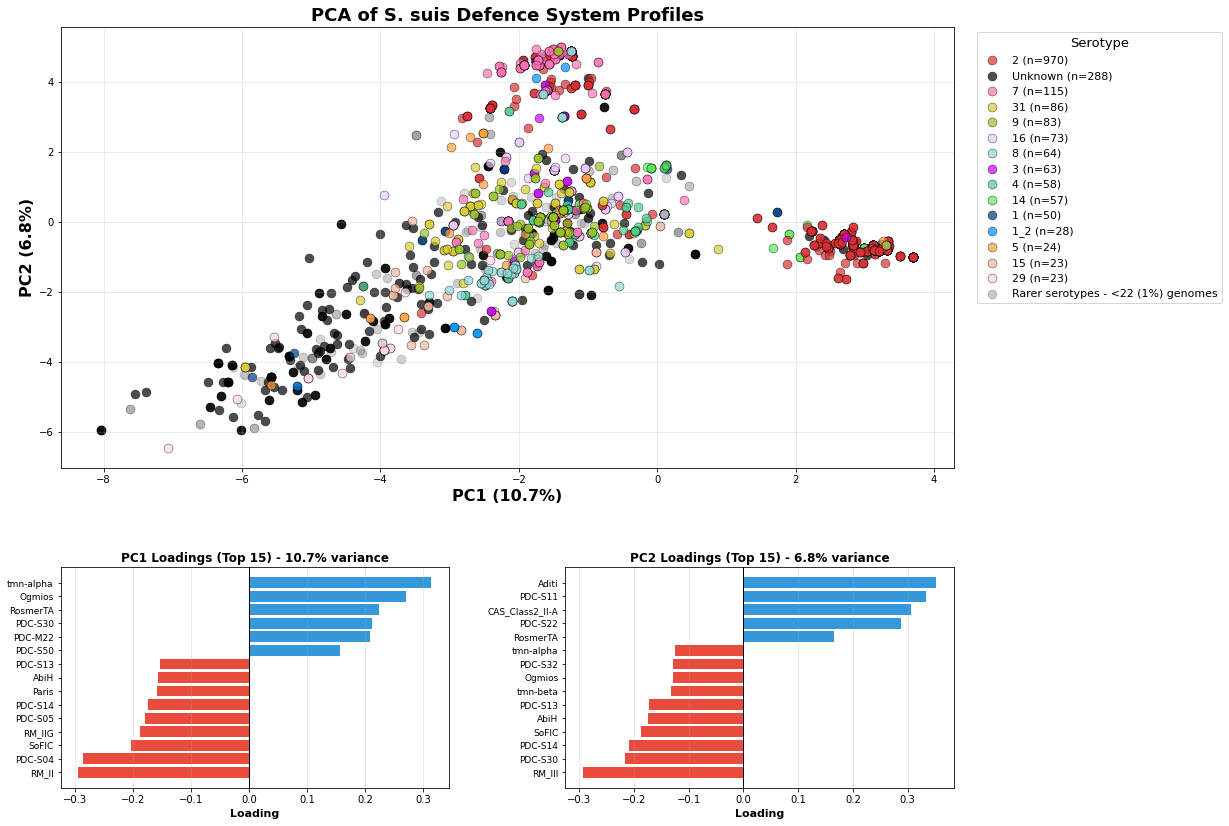

In [9]:

# 1. Binary presence/absence on the tmn-split matrix
defence_binary = (defence_df_tmn_split > 0).astype(int)

# 2. Keep informative systems: present in >=22 genomes (~1%), not unresolved
cols_to_keep = []
for col in defence_binary.columns:
    info = defence_metadata.get(col)
    if info is None:
        continue
    if (defence_binary[col] >= 1).sum() < 22:           continue
    if info['subtype'].lower() == 'subtype_unresolved': continue
    if info['outcome'] == 'Unresolved':                 continue
    cols_to_keep.append(col)
defence_binary_df = defence_binary[cols_to_keep]
print(f"Systems retained for PCA: {len(cols_to_keep)} of {defence_binary.shape[1]}")

# 3. Attach serotype labels
data = defence_binary_df.join(merged_df[['Serotype_Consensus']], how='inner')
data['Serotype_Consensus'] = (data['Serotype_Consensus']
                              .fillna('Unknown').replace({'-': 'Unknown', '': 'Unknown'}))
feature_columns = [c for c in data.columns if c != 'Serotype_Consensus']
X = data[feature_columns].values
y = data['Serotype_Consensus'].values

# 4. Standardise then PCA
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pc1_var, pc2_var = pca.explained_variance_ratio_[:2] * 100
print(f"PC1 = {pc1_var:.1f}%, PC2 = {pc2_var:.1f}%, total = {pc1_var + pc2_var:.1f}%")
results_pca = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'Serotype': y},
                           index=data.index)

# 5. Colours: file-defined serotypes, rarer (<22) greyscale, Unknown black
serotype_colour_map = {}
colour_df = pd.read_csv(COLOURS_FILE, header=None)
for _, row in colour_df.iterrows():
    st = str(row[0]).strip().strip('"').strip("'")
    cl = str(row[1]).strip().strip('"').strip("'")
    serotype_colour_map[st] = cl if cl.startswith('#') else '#' + cl

serotypes = sorted(results_pca['Serotype'].unique())
mapped   = [s for s in serotypes if str(s) in serotype_colour_map]
unmapped = [s for s in serotypes if str(s) not in serotype_colour_map]
def _grey(i, total):
    g = 0.5 if total == 1 else 0.3 + (i / (total - 1)) * 0.4
    v = int(g * 255); return f'#{v:02x}{v:02x}{v:02x}'
for i, s in enumerate(unmapped):
    serotype_colour_map[s] = _grey(i, max(len(unmapped), 1))

# 6. Loadings (top 15 per PC)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_columns)
def _subtype(col): return defence_metadata.get(col, {}).get('subtype', col)
pc1_top = loadings.loc[loadings['PC1'].abs().sort_values(ascending=False).head(15).index, 'PC1'].sort_values()
pc2_top = loadings.loc[loadings['PC2'].abs().sort_values(ascending=False).head(15).index, 'PC2'].sort_values()

# 7. Plot
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.3)
ax_pca = fig.add_subplot(gs[0, :])
ax_l1  = fig.add_subplot(gs[1, 0])
ax_l2  = fig.add_subplot(gs[1, 1])

plotted_rare = False
for s in unmapped:                      # rarer serotypes, back layer
    if s == 'Unknown':
        continue
    m = results_pca['Serotype'] == s
    if m.sum():
        ax_pca.scatter(results_pca.loc[m, 'PC1'], results_pca.loc[m, 'PC2'],
                       c=[serotype_colour_map[s]], s=80, alpha=0.3,
                       edgecolors='black', linewidth=0.5, zorder=0,
                       label='Rarer serotypes - <22 (1%) genomes' if not plotted_rare else '')
        plotted_rare = True
if 'Unknown' in serotypes:              # Unknown, middle layer (black)
    m = results_pca['Serotype'] == 'Unknown'
    ax_pca.scatter(results_pca.loc[m, 'PC1'], results_pca.loc[m, 'PC2'], c='black',
                   s=80, alpha=0.7, edgecolors='black', linewidth=0.5, zorder=1,
                   label=f'Unknown (n={m.sum()})')
for s in [x for x in mapped if x != 'Unknown']:   # mapped serotypes, front layer
    m = results_pca['Serotype'] == s
    if m.sum():
        ax_pca.scatter(results_pca.loc[m, 'PC1'], results_pca.loc[m, 'PC2'],
                       c=[serotype_colour_map[s]], s=80, alpha=0.7,
                       edgecolors='black', linewidth=0.5, zorder=2, label=f'{s} (n={m.sum()})')

ax_pca.set_xlabel(f'PC1 ({pc1_var:.1f}%)', fontsize=16, fontweight='bold')
ax_pca.set_ylabel(f'PC2 ({pc2_var:.1f}%)', fontsize=16, fontweight='bold')
ax_pca.set_title('PCA of S. suis Defence System Profiles', fontsize=18, fontweight='bold')
ax_pca.grid(alpha=0.3)
h, l = ax_pca.get_legend_handles_labels()
def _n(lbl): return int(lbl.split('(n=')[1].rstrip(')')) if '(n=' in lbl else 0
pairs = sorted(zip(l, h), key=lambda t: _n(t[0]), reverse=True)
l2, h2 = zip(*pairs) if pairs else ([], [])
ax_pca.legend(h2, l2, title='Serotype', bbox_to_anchor=(1.02, 1), loc='upper left',
              fontsize=11, title_fontsize=13)

for ax, top, var, lab in [(ax_l1, pc1_top, pc1_var, 'PC1'), (ax_l2, pc2_top, pc2_var, 'PC2')]:
    cols = ['#e74c3c' if v < 0 else '#3498db' for v in top.values]
    ax.barh(range(len(top)), top.values, color=cols)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([_subtype(c) for c in top.index], fontsize=9)
    ax.set_xlabel('Loading', fontsize=11, fontweight='bold')
    ax.set_title(f'{lab} Loadings (Top 15) - {var:.1f}% variance', fontsize=12, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIG_DIR / 'PCA_Draft3.png', dpi=400)
plt.show()

## 8. Figure 5 — co-occurrence (binomial-exact) heatmap

Coinfinder-style binomial-exact association / dissociation test on every pair of
defence subtypes present in >=22 genomes, BH-corrected (alpha = 0.1). Upper
triangle = associations, lower = dissociations, diagonal = genome counts. Saved
to `figures/defence_cooccurrence_heatmap.png`. *(This cell keeps the original,
heavily-commented implementation verbatim.)*

	77 systems retained, 72 excluded(unresolved systems or systems present in 22 or less genomes)
	Testing 2926 pairs (association mode...)
	629/2926 pairs significant at alpha=0.1 (bh)
	77 systems retained, 72 excluded(unresolved systems or systems present in 22 or less genomes)
	Testing 2926 pairs (dissociation mode...)
	160/2926 pairs significant at alpha=0.1 (bh)
Significant associations:	629
Significant dissocations:	160
Unique systems on axes:	71

Saved to: figures/defence_cooccurrence_heatmap.png


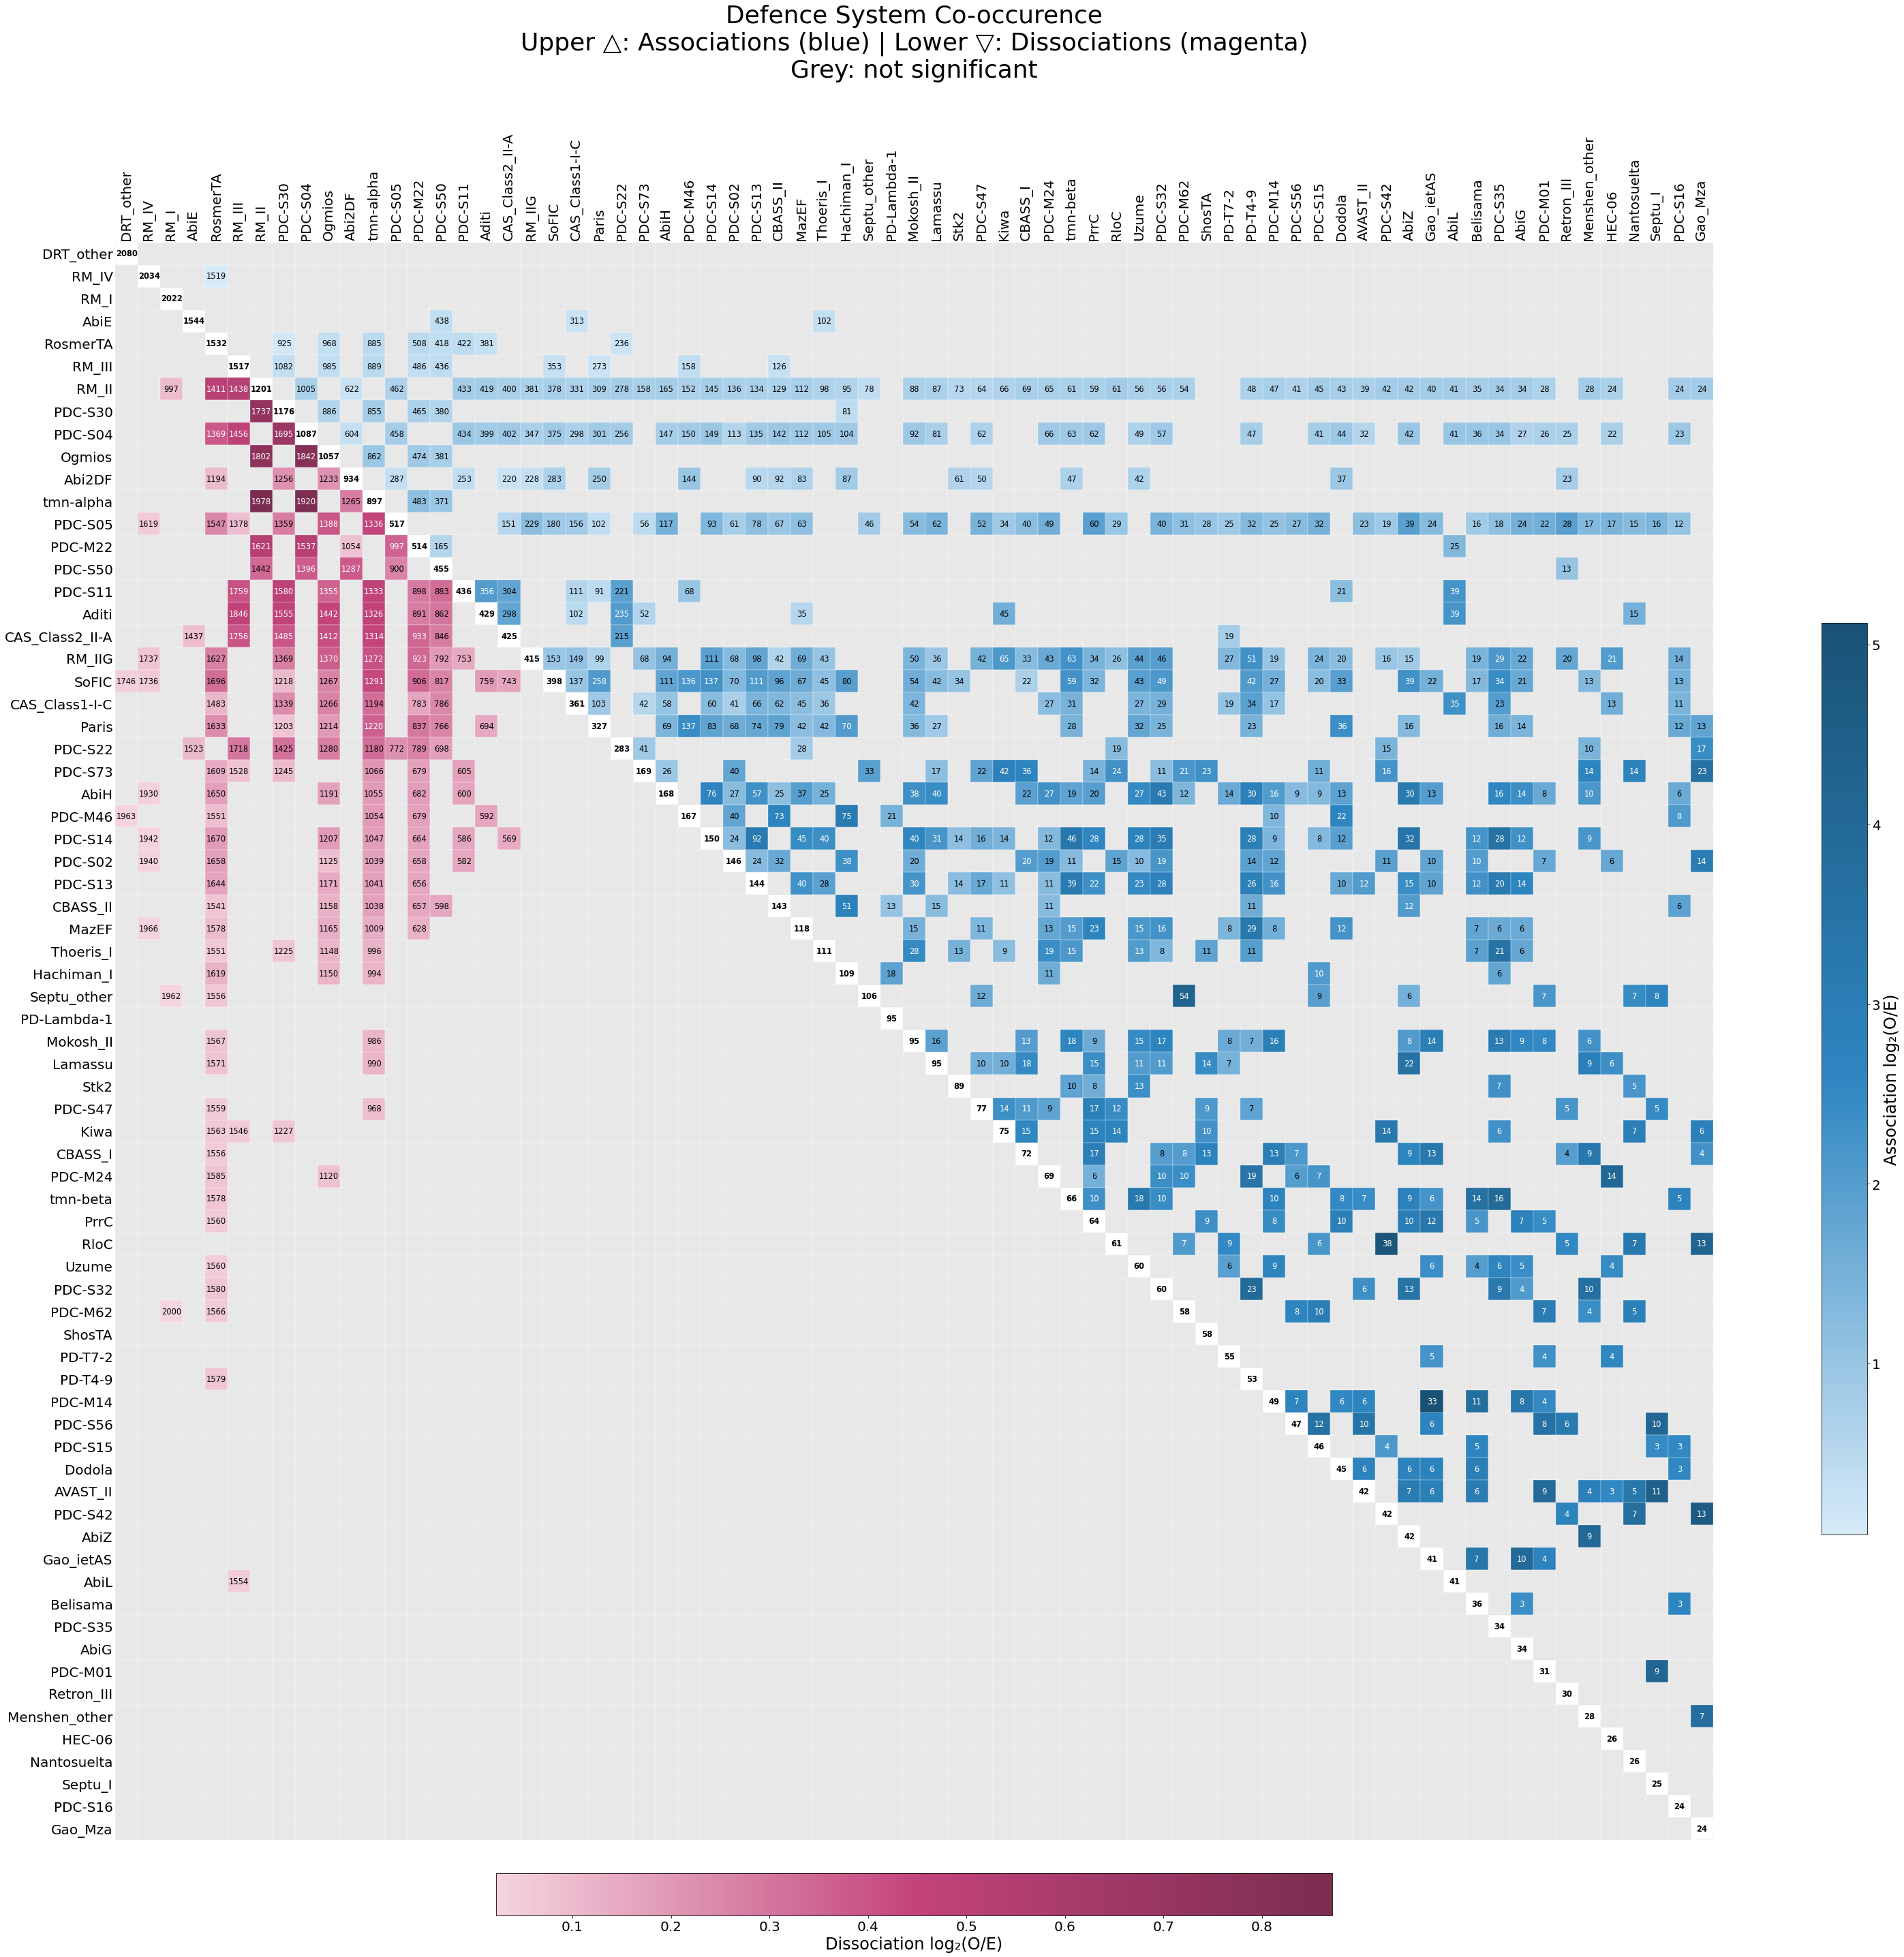


TOP 5 DISSOCIATIONS (by adjusted p-value)
                                                 sys1                                       sys2    p_adjusted  log2_O/E  observed  expected
           TYPE#Other#SUBTYPE#PDC-S04#OUTCOME#Unknown TYPE#tmn#SUBTYPE#tmn-alpha#OUTCOME#Unknown  0.000000e+00    0.8520      1920   1063.72
                TYPE#RM#SUBTYPE#RM_II#OUTCOME#Non-abi TYPE#tmn#SUBTYPE#tmn-alpha#OUTCOME#Unknown  0.000000e+00    0.8714      1978   1081.20
TYPE#Ogmios#SUBTYPE#Ogmios#OUTCOME#outcome_unresolved TYPE#Other#SUBTYPE#PDC-S04#OUTCOME#Unknown 2.951017e-280    0.7978      1842   1059.56
TYPE#Ogmios#SUBTYPE#Ogmios#OUTCOME#outcome_unresolved      TYPE#RM#SUBTYPE#RM_II#OUTCOME#Non-abi 1.046755e-248    0.7658      1802   1059.83
           TYPE#Other#SUBTYPE#PDC-S30#OUTCOME#Unknown      TYPE#RM#SUBTYPE#RM_II#OUTCOME#Non-abi 6.182993e-212    0.7346      1737   1043.94

TOP 5 ASSOCIATIONS (by adjusted p-value)
                                                   sys1              

In [10]:
# =============================================================================
# COMMENTED AND UNDERSTOOD EMMET VERSION
# =============================================================================

# =============================================================================
# SECTION 1: IMPORT DEPENDENCIES
# =============================================================================

from scipy.stats import binom
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle

# =============================================================================
# SECTION 2: TESTING FUNCTIONS
# =============================================================================

#### ACTUAL BINOMIAL EXACT TEST
def coinfinder_test(df, sys1, sys2, mode='association'):
	"""
	Recreation of the coinfinder test for association or dissociation
	between two defence systems
	"""

	# Define 'N', the number of genomes in the test
	N = len(df) # The number of rows in a dataframe of genomeID,sys1,sys2,...

	# Get rows that have system i (sys1)/ j (sys2)
	has_i = df[sys1] >= 1 # Genomes with sys1
	has_j = df[sys2] >= 1 # Genomes with sys2

	# Get count of genomes with systems
	N_i = has_i.sum()				# No. genomes with sys1
	N_j = has_j.sum()				# No. genomes with sys2
	N_ij = (has_i & has_j).sum()	# Num. genomes with BOTH systems

	# System probabilities
	P_i = N_i / N # Probability of gene i being in a genome, given num. genomes
	P_j = N_j / N # Probability of gene j being in a genome, given num. genomes

	# Code association mode
	if mode == 'association':
		E = P_i * P_j * N 						# Expected number of genomes with both systems, given probability of each gene and num. genomes
		O = N_ij								# Actual (Observed) number of genomes with both systems (Intersection of Venn Diagram)
		p_value = binom.sf(O - 1, N, P_i * P_j)	# Association-specific binomial exact test

	elif mode == 'dissociation':
		E = (P_i * (1 - P_j) + P_j * (1 - P_i)) * N 		# Expected num. genomes that have ONE OF BOTH systems, BUT NOT BOTH, given probability of having each gene
		O = N_i + N_j - 2 * N_ij					# Actual (Observed) num. genomes that have ONE of the systems, but NOT BOTH (Venn Diagram - outsections excluding intersection)
		p_prob = P_i * (1 - P_j) + P_j * (1 - P_i)	# Probability of having ONE but NOT BOTH systems
		p_value = binom.sf(O -1, N, p_prob)			# Dissociation-specific binomial exact test
	else:
		raise ValueError("mode must be 'association' or 'dissocation'")

	# Log2 fold enrichment of association/dissociation (how likely the ass/diss is)
	# Clipped to avoid Log_2(0) 
	# |- just in case, won't happen cos only using systems in >1% of genomes
	log2_OE = np.log2(max(O, 0.5) / max(E, 0.5))

	# Table of metrics to return
	return{
		'sys1': sys1, 'sys2': sys2,
		'N': int(N), 'N_i': int(N_i), 'N_j': int(N_j), 'N_ij': int(N_ij),
		'expected': round(E, 2), 'observed': int(O),
		'log2_O/E': round(log2_OE, 4),
		'p_value': p_value, 'mode': mode,
	}

#### MULTIPLE TESTING CORRECTION
def _apply_correction(results_df, method='benjamini-hochberg', alpha=0.1): # Apply Benjamini-Hochberg (FDR) correction and set new threshold to 0.1
	"""
	Apply multiple testing correction

	Parameters
	----------
	results_df : pd.DataFrame
		Results dataframe from coinfinder_test function
		Must contain 'p_value' column
	method : str
		'benjamini-hochberg' # Removed bonferroni functionality as not using
	alpha : float
		Significance threshold (default = 0.1)

	Returns
	-------
	pd.DataFrame with 'p_adjusted' and 'significant' columns added.
	"""

	# Get the number of statistical tests being performed
	n_tests = len(results_df)	# Num. pairwise tests from coinfinder_test

	if method in ('benjamini-hochberg', 'bh', 'fdr'):
		# Sort results by p-value for BH procedure
		results_df = results_df.sort_values('p_value').reset_index(drop=True)
		# Get the rank of each pariwise comparison
		ranks = np.arange(1, n_tests + 1)

		# BH adjusted p-values: p_adj = p * (n_tests / test rank)
		# Then enforce monotonicity (cumulative minimum form the bottom up)
		# Monotonicity: ensuring that a MORE-significant p-value never results in a LESS-significant adjusted p-value
		raw_adjusted = results_df['p_value'].values * (n_tests / ranks)
		# Ensure monotonicity by taking cumulative minimum from largest rank down
		adjusted = np.minimum.accumulate(raw_adjusted[::-1])[::-1]
		adjusted = np.clip(adjusted, 0, 1.0)

		# Save results
		results_df['p_adjusted'] = adjusted
		results_df['significant'] = results_df['p_adjusted'] < alpha

	elif method == 'bonferroni':
		print('Bonferroni functionality removed')
		exit()
	else:
		raise ValueError(f"Unknown corection method: '{method}'."
						f"Use 'benjamini-hochberg'/'bh'/'fdr'.")

	return results_df

#### FUNCTION TO DO ALL-AGAINST-ALL BINOMIAL EXACT
def coinfinder_all_pairs(df, systems_cols, mode='association', alpha=0.1,
						min_genomes=22, correction='benjamini-hochberg'):
	"""
	Run Binomial-Exact test on all pairs of defence systems with multiple testing correction

	Parameters
	----------
	df : pd.DataFrame
		Binary presence/absence dataframe - 'genomeID,sys1,sys2,...'
	system_cols : list
		Column names to test.
	mode : str
		'association' or 'dissociation'.
	alpha : float
		Significance threshold (to apply to corrected p-values).
	min_genomes : int
		Minimum number of genomes a system must be present in (22 = ~1% of 2,119)
	correction : str
		'benjamini-hochberg'/'bh'/'fdr' (Bonferroni functionality removed)

	Returns
	-------
	pd.DataFrame of results, sorted by p-value.
	"""

	# Remove 'subtype_unresolved' systems, these could have various functions and
	# are not biologically appropriate to test as a system
	# List comprehension
	# '...for c in cols'	= loop through each item in 'cols'
	# 'c for...'			= info we're using/keeping
	# 'if'					= condition to keep it
	cols = [c for c in systems_cols if 'subtype_unresolved' not in c.lower()]
	# Filter systems so only those present in at least min_genomes
	cols = [c for c in cols if (df[c] >= 1).sum() >= min_genomes]
	# Print to screen filters for user to see
	excluded = len(systems_cols) - len(cols)
	print(f"	{len(cols)} systems retained, {excluded} excluded"
		f"(unresolved systems or systems present in {min_genomes} or less genomes)")

	results = []

	# Create a list of all possible pariwise combinations of defence systems
	# gives every possible pairing, without repetition or order mattering
	pairs = list(combinations(cols, 2))
	n_tests = len(pairs) 				# Num. of tests to actually be performed
	print(f"	Testing {n_tests} pairs ({mode} mode...)")

	for s1, s2 in pairs:	# for every sys1, sys2 pair in list of all combos
		res = coinfinder_test(df, s1, s2, mode=mode)
		results.append(res)

	results_df = pd.DataFrame(results)

	# Apply correction method
	results_df = _apply_correction(results_df, method=correction, alpha=alpha)
	results_df = results_df.sort_values('p_value').reset_index(drop=True)

	# See how many pairs were significant after correction
	n_sig = results_df['significant'].sum()
	correction_label = correction.upper() if correction == 'BH (FDR)' else correction
	print(f"	{n_sig}/{n_tests} pairs significant at alpha={alpha} ({correction_label})")

	return results_df


# =============================================================================
# SECTION 3: PLOTTING SPLIT HEATMAP
# =============================================================================

# Function to take the subtype from column header
# Column format: TYPE#X#SUBTYPE#Y#OUTCOME#Z
def _extract_subtype(col_name):
	"""Extract the subtype from a column name"""
	parts = col_name.split('#')
	try:
		return parts[parts.index('SUBTYPE') + 1]	# Find the part containing 'SUBTYPE' and return index after
	except (ValueError, IndexError):
		return col_name								# Just return whole column name if that doesn't work

# Function to plot a split heatmap for assoc/dissoc
def plot_split_heatmap(
	assoc_df,
	dissoc_df,
	defence_df,
	alpha=0.1,
	figsize_per_system=1,
	min_fig=10,
	max_fig=40,
	annot_fontsize=11.5,
	label_fontsize=20,
	save_path=None,
	dpi=300,
	):
	
	"""
	Plot a split heatmap of significant defence system associations/dissociations.

	Upper triangle:	Associations (ocean blue)
	Lower triangle:	Dissociations (magenta)
	Diagonal:		Genome count (N_i) as text on white background
	Cell values:	O_A (association) or O_D (dissociation)
	Grey cells:		Not significant after correction

	Parameters
	----------
	assoc_df : pd.DataFrame
		Output from coinfinder_all_pairs(..., mode='association')
	dissoc_df : pd.DataFrame
		Output from coinfinder_all_pairs(..., mode='dissociation')
	defence_df : pd.DataFrame
		Defence system presence/absence dataframe (genomes x systems)
	alpha : float
		Significance threshold (on p_adjusted)
	save_path : str or None
		If provided, save the figure to this path

	Returns
	-------
	fig, ax
	"""

	# 1. FILTER TO SIGNIFICANT PAIRS ONLY
	# -----------------------------------------------------------------
	sig_assoc = assoc_df[assoc_df['significant']].copy()	# Mask non-significant association rows and copy to new dataframe
	sig_dissoc = dissoc_df[dissoc_df['significant']].copy()	# Mask non-significant dissociation rows and copy to new dataframe

	print(f"Significant associations:	{len(sig_assoc)}")
	print(f"Significant dissocations:	{len(sig_dissoc)}")

	# 2. CALCULATE LOG2(O/E) IF NOT ALREADY THERE
	# -----------------------------------------------------------------
	if 'log2_O/E' not in sig_assoc.columns:
		sig_assoc['log2_OE'] = np.log2(
			sig_assoc['N_ij'].clip(lower=0.5) / sig_assoc['expected'].clip(lower=0.5)
		)

	if 'log2_O/E' not in sig_dissoc.columns:
		sig_dissoc['log2_OE'] = np.log2(
			sig_dissoc['observed'].clip(lower=0.5) / sig_dissoc['expected'].clip(lower=0.5)
		)

	# 3. GET UNIQUE SYSTEM NAMES AND ORDER THEM BY FREQUENCY(!!!)
	# -----------------------------------------------------------------
	all_systems = set()								# Make an empty set to add the names to
	for df_tmp in [sig_assoc, sig_dissoc]:			# df_tmp becomes 'sig_assoc' in first iteration, then 'sig_dissoc' in second
		all_systems.update(df_tmp['sys1'].values)	# Update set with unique sys1 values from both dataframes
		all_systems.update(df_tmp['sys2'].values)	# Update set with unique sys2 values from both dataframes

	system_freq = {}											# Make an empty dictionary to get frequencies
	for s in all_systems:										# For every defence system...
		if s in defence_df.columns:								# if the defence system is in the pres/abs dataframe...
			system_freq[s] = int((defence_df[s] >= 1).sum())	# ...set 's' key, value to how many genomes it is in
		else:													# otherwise
			system_freq[s] = 0 									# set the count to 0 (absent)

	# Use the method sorted()...
	# ...To sort the list 'all_systems'...
	# ...based on the sorting criteria: 'for each item (x) in the dictionary, look up x's frequency'...
	# ...(if its not in the dictionary, set the frequency to 0)...
	# ...reverse = True sorts it into descending order
	# ...save it all as a list to 'systems'
	systems = sorted(all_systems, key=lambda x: system_freq.get(x, 0), reverse = True)
	n = len(systems)
	# Create a dictionary 'sys_to_idx'...
	# 'enumerate(systems)' pairs each system with it's position...
	# '...for i, s in enumerate(systems)' unpacks each pair into the index 'i' and system name 's'
	# 's: i' sets the dictionary key, value pairs
	# result: {'sys1': 0, 'sys2': 1}
	# Indexes systems based on their frequency (systems)
	sys_to_idx = {s: i for i, s in enumerate(systems)}

	print(f"Unique systems on axes:	{n}")

	if n == 0:
		print("No significant pairs to plot!")
		return None, None

	# 4. BUILD LOOKUP DICITONARIES
	# -----------------------------------------------------------------
	assoc_lookup = {}
	for _, row in sig_assoc.iterrows():					# '_' = throwaway variable, 'row' yields the row
		s1, s2 = row['sys1'], row['sys2']				# assigns s1 and s2 as the systems of the row
		if s1 in sys_to_idx and s2 in sys_to_idx:		# if both of these systems are in the sorted, indexed list of systems...
			i, j = sys_to_idx[s1], sys_to_idx[s2]		# ...finds the indexes of those systems and assigns them to i, j
			key = (min(i, j), max(i, j))				# ...orders them based on lowest index first (min between i + j, then max between i + j)
			assoc_lookup[key] = {						# Creates a dictionary entry, where the key is the "systems index coordinates" kinda
				'log2_O/E': row['log2_O/E'],			# Value (first bit) is the log2 of the Observed/Expected (what will be used to colour the cell)
				'cell_value': int(row['N_ij'])			# 'cell_value' is set to number of genomes with both of the systems (what'll be displayed inside the cell)
			}											# Entry example: {(0,1): {'log2_O/E': 2.5, 'cell_value': 2}}

	# Repeat for dissociation triangle
	dissoc_lookup = {}
	for _, row in sig_dissoc.iterrows():
		s1, s2 = row['sys1'], row['sys2']
		if s1 in sys_to_idx and s2 in sys_to_idx:
			i, j = sys_to_idx[s1], sys_to_idx[s2]
			key = (min(i, j), max(i,j))
			dissoc_lookup[key] = {
				'log2_O/E': row['log2_O/E'],
				'cell_value': int(row['observed']),
			}

	# 5. COLOUR MAPS AND NORMALISATION
	# -----------------------------------------------------------------	
	# Set association colours
	assoc_cmap = mcolors.LinearSegmentedColormap.from_list(
		'ocean_blue', ['#d6eaf8', '#2e86c1', '#1a5276'], N=256
		)
	# Set dissociation colours
	dissoc_cmap = mcolors.LinearSegmentedColormap.from_list(
		'pastel_magenta', ['#f5d5e0', '#c3447a', '#7b2d50'], N=256
		)

	# 'assoc_lookup.values()' gets all values from the assoc_lookup dictionary
	# v['log2_O/E'] accesses the 'log2_O/E' key from each value v
	# '...for v in...' is list comprehensiont o collect all log odds ratio values into a single list
	assoc_vals = [v['log2_O/E'] for v in assoc_lookup.values()]
	dissoc_vals = [v['log2_O/E'] for v in dissoc_lookup.values()]
	assoc_norm = mcolors.Normalize(
		vmin=min(assoc_vals) if assoc_vals else 0,		# Set vmin to be the smallest assoc_vals value, if assoc_vals exists, otherwise set to 0
		vmax=max(assoc_vals) if assoc_vals else 1,		# Set vmax to be the largest assoc_vals value, if assoc_vals exists, otherwise set to 1
		)
	# Same for dissoc
	dissoc_norm = mcolors.Normalize(
		vmin=min(dissoc_vals) if dissoc_vals else 0,	# Same as assoc
		vmax=max(dissoc_vals) if dissoc_vals else 1,	# Same as assoc
		)

	# 6. DRAW THE HEATMAP
	# -----------------------------------------------------------------
	figsize = np.clip(n * figsize_per_system, min_fig, max_fig)				# Set the figure size to be n*figsize_per_system IF that value is not below min_fig, OR above max_fig

	# 'fig' is overall window/canvas, 'ax' is the plot area
	# 'plt.subplots()' returns 2 objects, so two variables needed to capture them
	fig, ax = plt.subplots(figsize=(figsize, figsize))								# sets the axis to be square (figsize x figsize)

	# Set specific shade of grey
	grey_colour = '#E8E8E8'

	for i in range(n):																# range(100) would be [0, 1, 2, ..., 99]
		for j in range(n):															# starting iteration, both i and j are '0'
			x, y = j, n - 1 - i 													# so (x, y) will be (0, (100 - 1 - o)) or (0, 99) | second inner iteraiton: (1, 99) | second out iteration: (0, 98)

			if i == j:																# If both idicies are the same, this is a DIAGONAL CELL, so put system frequency in there
				#--- DIAGONAL: genome count on white background
				ax.add_patch(plt.Rectangle(											# add_patch() creates a rectangle
					(x,y), 1, 1,													# at co-ordinates x,y, with dimensions 1x1
					facecolor='white', edgecolor='#CCCCCC', linewidth=0.3			# what it looks like
					))

				freq = system_freq.get(systems[i], 0)								# Looks up 'system[i]' key match in systems_freq and returns the value (', 0' means to return 0 instead of an error)
				ax.text(
					x + 0.5, y + 0.5, str(freq),									# x,y would be bottom left of box, +0.5 of a 1 box puts it in centre
					ha='center', va='center',	
					fontsize=annot_fontsize, fontweight='bold', color='black'	
					)

			elif i < j:																	# Heatmap being built from top-left to top-right, so when i<j, the y-inversion logic (n-1-i) makes this an upper triangle coordinate
				#--- UPPER TRIANGLE: Associations ---
				key = (i, j)
				if key in assoc_lookup:
					entry = assoc_lookup[key]
					colour = assoc_cmap(assoc_norm(entry['log2_O/E']))					# If the systems index pair (i,j) is in the lookup key, colour it according to the log2_O/E
					ax.add_patch(plt.Rectangle(
						(x, y), 1, 1,
						facecolor=colour, edgecolor='white', linewidth=0.3
						))
					brightness = 0.299*colour[0] + 0.587*colour[1] + 0.114*colour[2]	# Calculating the perceived brightness (RGB tuple)
					ax.text(
						x + 0.5, y + 0.5, str(entry['cell_value']),
						ha='center', va='center', fontsize=annot_fontsize,
						color='white' if brightness < 0.55 else 'black'					# Takes the perceived brightness and colours text white or black depending on how dark it is!
						)
				else:
					ax.add_patch(plt.Rectangle(
						(x, y), 1, 1,
						facecolor=grey_colour, edgecolor='white', linewidth=0.3
						))
			
			else:
				#--- LOWER TRIANGLE: Dissociations ---
				key = (min(i, j), max(i, j))
				if key in dissoc_lookup:
					entry = dissoc_lookup[key]
					colour = dissoc_cmap(dissoc_norm(entry['log2_O/E']))				
					ax.add_patch(plt.Rectangle(
						(x, y), 1, 1,
						facecolor=colour, edgecolor='white', linewidth=0.3
						))
					brightness = 0.299*colour[0] + 0.587*colour[1] + 0.114*colour[2]	
					ax.text(
						x + 0.5, y + 0.5, str(entry['cell_value']),
						ha='center', va='center', fontsize=annot_fontsize,
						color='white' if brightness < 0.55 else 'black'					
						)
				else:
					ax.add_patch(plt.Rectangle(
						(x, y), 1, 1,
						facecolor=grey_colour, edgecolor='white', linewidth=0.3
						))


	# 7. AXIS LABELS — x on TOP, y on LEFT
	# -----------------------------------------------------------------
	labels = [_extract_subtype(s) for s in systems]
	ax.set_xlim(0, n)
	ax.set_ylim(0, n)	# Setting axes to be the length of the data set

	# x-axis on the top of the graph, not the bottom
	ax.xaxis.set_ticks_position('top')
	ax.xaxis.set_label_position('top')

	ax.set_xticks([i + 0.5 for i in range(n)])											# Sets ticks to appear in the middle of the column rather than the edges
	ax.set_xticklabels(labels, rotation=90, ha='center', fontsize=label_fontsize)		

	# y-axis on left
	ax.set_yticks([i + 0.5 for i in range(n)])											# Sets the ticks to appear in the middle of the row rather thant the edges
	ax.set_yticklabels([labels[n - 1 - i] for i in range(n)], fontsize=label_fontsize)	# Sets reversed label order because of y-axis inversion

	ax.tick_params(length=0)																# Setting length to 0 makes tick marks invisible
	ax.set_aspect('equal')																# Forces aspect ration to be 1:1 so everything stays square no matter what viewing format

	for spine in ax.spines.values():														# Removes border box around plot, by looping through them (ax.spines is a dictionary)
		spine.set_visible(False)


	# 8. COLOUR BARS
	# -----------------------------------------------------------------
	sm_assoc = plt.cm.ScalarMappable(cmap=assoc_cmap, norm=assoc_norm)					# ScalarMappable maps numerical values to colours
	sm_assoc.set_array([])																# Initialising scalarmappable with an empty array
	cbar_a = fig.colorbar(																# Create a colourbar
		sm_assoc, ax=ax, fraction=0.025, pad=0.02,										# ax=ax means attach to the axis 'ax', fraction is the width as a fraction of the whole plot width (0.025=2.5%), pad is the space between the plot and the colourbar
		location='right', label='Association log\u2082(O/E)'
		)
	cbar_a.ax.tick_params(labelsize=20)													# Set numbers font on bar
	cbar_a.set_label('Association log\u2082(O/E)', fontsize=24)							# Set title size cos annoyingly couldn't do it in fig.colorbar()

	sm_dissoc = plt.cm.ScalarMappable(cmap=dissoc_cmap, norm=dissoc_norm)
	sm_dissoc.set_array([])
	cbar_d = fig.colorbar(
		sm_dissoc, ax=ax, fraction=0.025, pad=0.02,
		location='bottom', label='Dissociation log\u2082(O/E)',
		orientation='horizontal'
		)
	cbar_d.ax.tick_params(labelsize=20)
	cbar_d.set_label('Dissociation log\u2082(O/E)', fontsize=24)

	# 9. TITLE
	# -----------------------------------------------------------------					# Emmet this sections pretty self explanatory
	ax.set_title(
		'Defence System Co-occurence\n'
		'Upper \u25B3: Associations (blue) | Lower \u25BD: Dissociations (magenta)\n'
		'Grey: not significant',
		fontsize=36, pad=80
			)

	plt.tight_layout()

	if save_path:
		fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
		print(f"\nSaved to: {save_path}")

	plt.show()

	return fig, ax

# =============================================================================
# SECTION 4: RUN THE CODE
# =============================================================================
system_cols = [c for c in defence_df_tmn_split.columns]									# list comprehension through the defence columns to make a list of names

assoc_results = coinfinder_all_pairs(
	defence_df_tmn_split, system_cols, mode='association',
	min_genomes=22, correction='bh', alpha=0.1
	)

dissoc_results = coinfinder_all_pairs(
	defence_df_tmn_split, system_cols, mode='dissociation',
	min_genomes=22, correction='bh', alpha=0.1
	)

# --- Plot the heatmap ---
fig, ax = plot_split_heatmap(
	assoc_results,
	dissoc_results,
	defence_df_tmn_split,
	save_path=str(FIG_DIR / 'defence_cooccurrence_heatmap.png'),
	dpi=300
	)

# Top 5 by adjusted p-value
top_dissoc_pval = dissoc_results.nsmallest(5, 'p_adjusted')
top_assoc_pval = assoc_results.nsmallest(5, 'p_adjusted')

# Top 5 by log2(O/E) (strongest effects)
top_dissoc_effect = dissoc_results.nsmallest(5, 'log2_O/E')  # Most negative
top_assoc_effect = assoc_results.nlargest(5, 'log2_O/E')     # Most positive

print("\n" + "="*80)
print("TOP 5 DISSOCIATIONS (by adjusted p-value)")
print("="*80)
print(top_dissoc_pval[['sys1', 'sys2', 'p_adjusted', 'log2_O/E', 'observed', 'expected']].to_string(index=False))

print("\n" + "="*80)
print("TOP 5 ASSOCIATIONS (by adjusted p-value)")
print("="*80)
print(top_assoc_pval[['sys1', 'sys2', 'p_adjusted', 'log2_O/E', 'N_ij', 'expected']].to_string(index=False))

print("\n" + "="*80)
print("TOP 5 DISSOCIATIONS (by effect size)")
print("="*80)
print(top_dissoc_effect[['sys1', 'sys2', 'log2_O/E', 'p_adjusted', 'observed', 'expected']].to_string(index=False))

print("\n" + "="*80)
print("TOP 5 ASSOCIATIONS (by effect size)")
print("="*80)
print(top_assoc_effect[['sys1', 'sys2', 'log2_O/E', 'p_adjusted', 'N_ij', 'expected']].to_string(index=False))